# Test 9: AR Order Selection for Topic Series

**Motivation:**  
The main estimation pipeline extracts AR(1) innovations from the topic series before running the cross-sectional LASSO. This notebook tests whether AR(1) is actually the right model for these series, or whether a different order (including AR(0) = white noise) would be more appropriate.

**Procedure for each topic:**
1. ADF unit-root test — check the series is stationary
2. Fit AR(p) for p = 0, …, 6 and record AIC and BIC
3. Select best order by AIC and by BIC
4. Ljung-Box test on AR(1) residuals — check whether AR(1) is sufficient
5. PACF plots for a representative sample of topics

**Conclusion criteria:**  
- If the majority of topics are best described by AR(1) under both AIC and BIC, the current assumption is supported.
- If many topics prefer AR(0) (white noise) or higher orders, the preprocessing step should be reconsidered.

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')

DATA_PATH = Path('../../data/Daily_Topic_Attention_Theta.csv')
MAX_AR_ORDER = 6
ADF_ALPHA    = 0.05   # significance level for stationarity test
LB_ALPHA     = 0.05   # significance level for Ljung-Box test
N_SAMPLE_PACF = 12    # number of topics to show PACF plots for

## 1. Load data

In [2]:
topics_df = pd.read_csv(DATA_PATH, index_col='date', parse_dates=True)
topics_df = topics_df.sort_index()

print(f'Shape          : {topics_df.shape}')
print(f'Date range     : {topics_df.index.min().date()} — {topics_df.index.max().date()}')
print(f'Number of topics: {topics_df.shape[1]}')
print(f'\nFirst 5 topic names: {list(topics_df.columns[:5])}')
topics_df.head(3)

Shape          : (8512, 180)
Date range     : 1984-01-02 — 2017-06-30
Number of topics: 180

First 5 topic names: ['Natural disasters', 'Internet', 'Soft drinks', 'Mobile devices', 'Profits']


,Natural disasters,Internet,Soft drinks,Mobile devices,Profits,M&A,Changes,Police/crime,Research,Executive pay,...,European politics,Size,NASD,Mexico,Retail,Long/short term,Wide range,Lawsuits,UK,Revenue growth
date,,,,,,,,,,,,,,,,,,,,,
1984-01-02,0.001884,0.000628,0.003698,0.001116,0.005407,0.004500,0.002303,0.003244,0.007152,0.003838,...,0.008687,0.004291,0.002268,0.003977,0.002442,0.003628,0.005303,0.004012,0.007710,0.003140
1984-01-03,0.003409,0.001263,0.001768,0.002062,0.004967,0.006861,0.003746,0.003409,0.004419,0.004251,...,0.006440,0.004630,0.004798,0.005893,0.003578,0.003325,0.003367,0.010144,0.004167,0.001810
1984-01-04,0.004119,0.000909,0.002835,0.002461,0.007329,0.004654,0.002835,0.005991,0.004493,0.006633,...,0.013534,0.001765,0.004226,0.005670,0.012143,0.005296,0.004707,0.010003,0.004547,0.002247


## 2. Helper functions

In [3]:
def adf_test(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF test; return dict with stat, p-value and stationarity verdict."""
    s = series.dropna()
    stat, pval, _, _, crit, _ = adfuller(s, autolag='AIC')
    return {'adf_stat': stat, 'adf_pval': pval, 'stationary': pval < alpha}


def fit_ar_orders(series: pd.Series, max_order: int = 6) -> pd.DataFrame:
    """
    Fit AR(p) for p = 0 … max_order using OLS (AutoReg).
    Returns a DataFrame with columns [order, aic, bic, llf, nobs].
    """
    s = series.dropna()
    rows = []
    for p in range(0, max_order + 1):
        try:
            res = AutoReg(s, lags=p, old_names=False).fit()
            rows.append({'order': p, 'aic': res.aic, 'bic': res.bic,
                         'llf': res.llf, 'nobs': res.nobs})
        except Exception:
            pass
    return pd.DataFrame(rows)


def ljung_box_on_ar1_resid(series: pd.Series, lags: int = 10,
                            alpha: float = 0.05) -> dict:
    """
    Fit AR(1) and run Ljung-Box test on residuals.
    Returns p-value at the specified maximum lag and whether AR(1) is sufficient
    (i.e., residuals look like white noise).
    """
    s = series.dropna()
    if len(s) < 30:
        return {'lb_pval_min': np.nan, 'ar1_sufficient': np.nan}
    res = AutoReg(s, lags=1, old_names=False).fit()
    lb = acorr_ljungbox(res.resid, lags=lags, return_df=True)
    # Use the minimum p-value across all tested lags (conservative)
    min_pval = lb['lb_pvalue'].min()
    return {'lb_pval_min': min_pval, 'ar1_sufficient': min_pval > alpha}

## 3. Run tests across all topics

In [4]:
results = []

for col in topics_df.columns:
    s = topics_df[col].dropna()
    if len(s) < 30 or s.nunique() < 3:
        continue

    # ADF
    adf = adf_test(s, alpha=ADF_ALPHA)

    # AR order selection
    orders_df = fit_ar_orders(s, max_order=MAX_AR_ORDER)
    best_aic = int(orders_df.loc[orders_df['aic'].idxmin(), 'order'])
    best_bic = int(orders_df.loc[orders_df['bic'].idxmin(), 'order'])

    # Ljung-Box on AR(1) residuals
    lb = ljung_box_on_ar1_resid(s, alpha=LB_ALPHA)

    results.append({
        'topic'          : col,
        'nobs'           : len(s),
        'adf_stat'       : adf['adf_stat'],
        'adf_pval'       : adf['adf_pval'],
        'stationary'     : adf['stationary'],
        'best_aic_order' : best_aic,
        'best_bic_order' : best_bic,
        'lb_pval_min'    : lb['lb_pval_min'],
        'ar1_sufficient' : lb['ar1_sufficient'],
    })

results_df = pd.DataFrame(results).set_index('topic')
print(f'Topics analysed: {len(results_df)}')
results_df.head(10)

Topics analysed: 180


,nobs,adf_stat,adf_pval,stationary,best_aic_order,best_bic_order,lb_pval_min,ar1_sufficient
topic,,,,,,,,
Natural disasters,8512,-12.266976,8.815043e-23,True,5,5,5.307481e-191,False
Internet,8512,-2.543944,1.051450e-01,False,6,6,0.000000e+00,False
Soft drinks,8512,-10.437274,1.554607e-18,True,6,4,5.576257e-38,False
Mobile devices,8512,-2.804104,5.768987e-02,False,6,6,0.000000e+00,False
Profits,8512,-14.548209,5.016377e-27,True,5,5,0.000000e+00,False
M&A,8512,-5.196615,8.933055e-06,True,6,6,5.387683e-270,False
Changes,8512,-3.638612,5.064332e-03,True,6,6,0.000000e+00,False
Police/crime,8512,-4.851099,4.338052e-05,True,6,6,0.000000e+00,False
Research,8512,-7.145186,3.246572e-10,True,6,6,9.930737e-129,False


## 4. Stationarity summary

In [5]:
n_total      = len(results_df)
n_stationary = results_df['stationary'].sum()
n_unit_root  = n_total - n_stationary

print(f'Stationary (ADF p < {ADF_ALPHA}): {n_stationary}/{n_total}  ({100*n_stationary/n_total:.1f}%)')
print(f'Possible unit root               : {n_unit_root}/{n_total}  ({100*n_unit_root/n_total:.1f}%)')

if n_unit_root > 0:
    print('\nTopics with possible unit root:')
    display(results_df[~results_df['stationary']][['adf_stat', 'adf_pval']].sort_values('adf_pval', ascending=False))

Stationary (ADF p < 0.05): 167/180  (92.8%)
Possible unit root               : 13/180  (7.2%)

Topics with possible unit root:


,adf_stat,adf_pval
topic,,
International exchanges,-1.463877,0.551299
Small caps,-1.832717,0.364344
Corrections/amplifications,-2.150928,0.224535
Treasury bonds,-2.192104,0.209124
Futures/indices,-2.242870,0.191055
Mid-level executives,-2.360443,0.153214
NY politics,-2.379268,0.147674
Convertible/preferred,-2.429369,0.133618
People familiar,-2.511708,0.112652


## 5. AR order selection — distribution across topics

In [6]:
aic_counts = results_df['best_aic_order'].value_counts().sort_index()
bic_counts = results_df['best_bic_order'].value_counts().sort_index()

print('=== Best AR order by AIC ===')
for p, cnt in aic_counts.items():
    print(f'  AR({p}): {cnt:3d} topics  ({100*cnt/n_total:.1f}%)')

print('\n=== Best AR order by BIC ===')
for p, cnt in bic_counts.items():
    print(f'  AR({p}): {cnt:3d} topics  ({100*cnt/n_total:.1f}%)')

=== Best AR order by AIC ===
  AR(0):   2 topics  (1.1%)
  AR(1):   2 topics  (1.1%)
  AR(5):  27 topics  (15.0%)
  AR(6): 149 topics  (82.8%)

=== Best AR order by BIC ===
  AR(0):   3 topics  (1.7%)
  AR(1):   5 topics  (2.8%)
  AR(2):   1 topics  (0.6%)
  AR(3):   1 topics  (0.6%)
  AR(4):   2 topics  (1.1%)
  AR(5):  30 topics  (16.7%)
  AR(6): 138 topics  (76.7%)


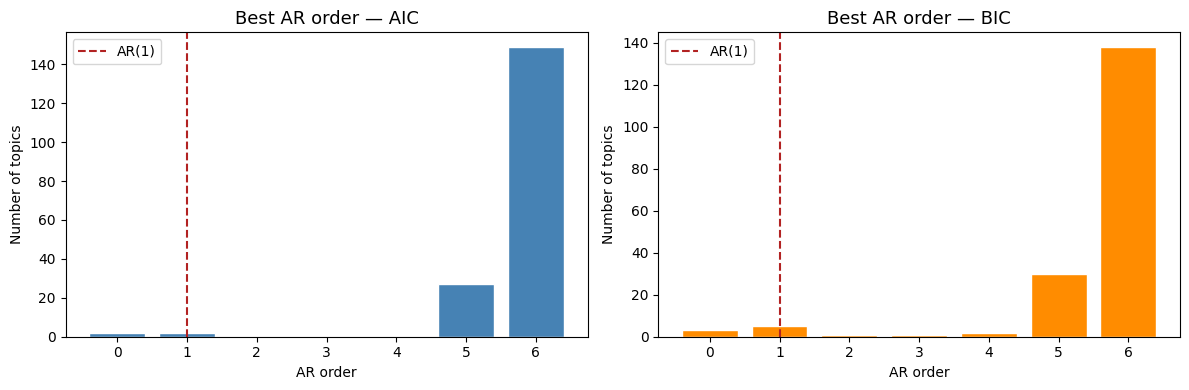

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_orders = range(0, MAX_AR_ORDER + 1)

aic_vals = [aic_counts.get(p, 0) for p in all_orders]
bic_vals = [bic_counts.get(p, 0) for p in all_orders]

axes[0].bar(all_orders, aic_vals, color='steelblue', edgecolor='white')
axes[0].set_title('Best AR order — AIC', fontsize=13)
axes[0].set_xlabel('AR order')
axes[0].set_ylabel('Number of topics')
axes[0].set_xticks(list(all_orders))
axes[0].axvline(1, color='firebrick', linestyle='--', linewidth=1.5, label='AR(1)')
axes[0].legend()

axes[1].bar(all_orders, bic_vals, color='darkorange', edgecolor='white')
axes[1].set_title('Best AR order — BIC', fontsize=13)
axes[1].set_xlabel('AR order')
axes[1].set_ylabel('Number of topics')
axes[1].set_xticks(list(all_orders))
axes[1].axvline(1, color='firebrick', linestyle='--', linewidth=1.5, label='AR(1)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Ljung-Box test — is AR(1) sufficient?

In [8]:
n_sufficient    = results_df['ar1_sufficient'].sum()
n_insufficient  = (~results_df['ar1_sufficient']).sum()

print(f'AR(1) residuals consistent with white noise (LB p > {LB_ALPHA}): '
      f'{n_sufficient}/{n_total}  ({100*n_sufficient/n_total:.1f}%)')
print(f'AR(1) residuals show remaining autocorrelation            : '
      f'{n_insufficient}/{n_total}  ({100*n_insufficient/n_total:.1f}%)')

print('\nTopics where AR(1) is NOT sufficient (LB min p-value):')
display(
    results_df[~results_df['ar1_sufficient']][['best_aic_order', 'best_bic_order', 'lb_pval_min']]
    .sort_values('lb_pval_min')
)

AR(1) residuals consistent with white noise (LB p > 0.05): 0/180  (0.0%)
AR(1) residuals show remaining autocorrelation            : 180/180  (100.0%)

Topics where AR(1) is NOT sufficient (LB min p-value):


,best_aic_order,best_bic_order,lb_pval_min
topic,,,
Revenue growth,6,6,0.000000e+00
Currencies/metals,6,6,0.000000e+00
Financial crisis,6,6,0.000000e+00
Mortgages,6,6,0.000000e+00
Financial reports,6,6,0.000000e+00
...,...,...,...
Wide range,0,0,8.764049e-15
Luxury/beverages,5,1,1.727932e-08
NASD,0,0,2.329336e-07


## 7. PACF plots for a sample of topics

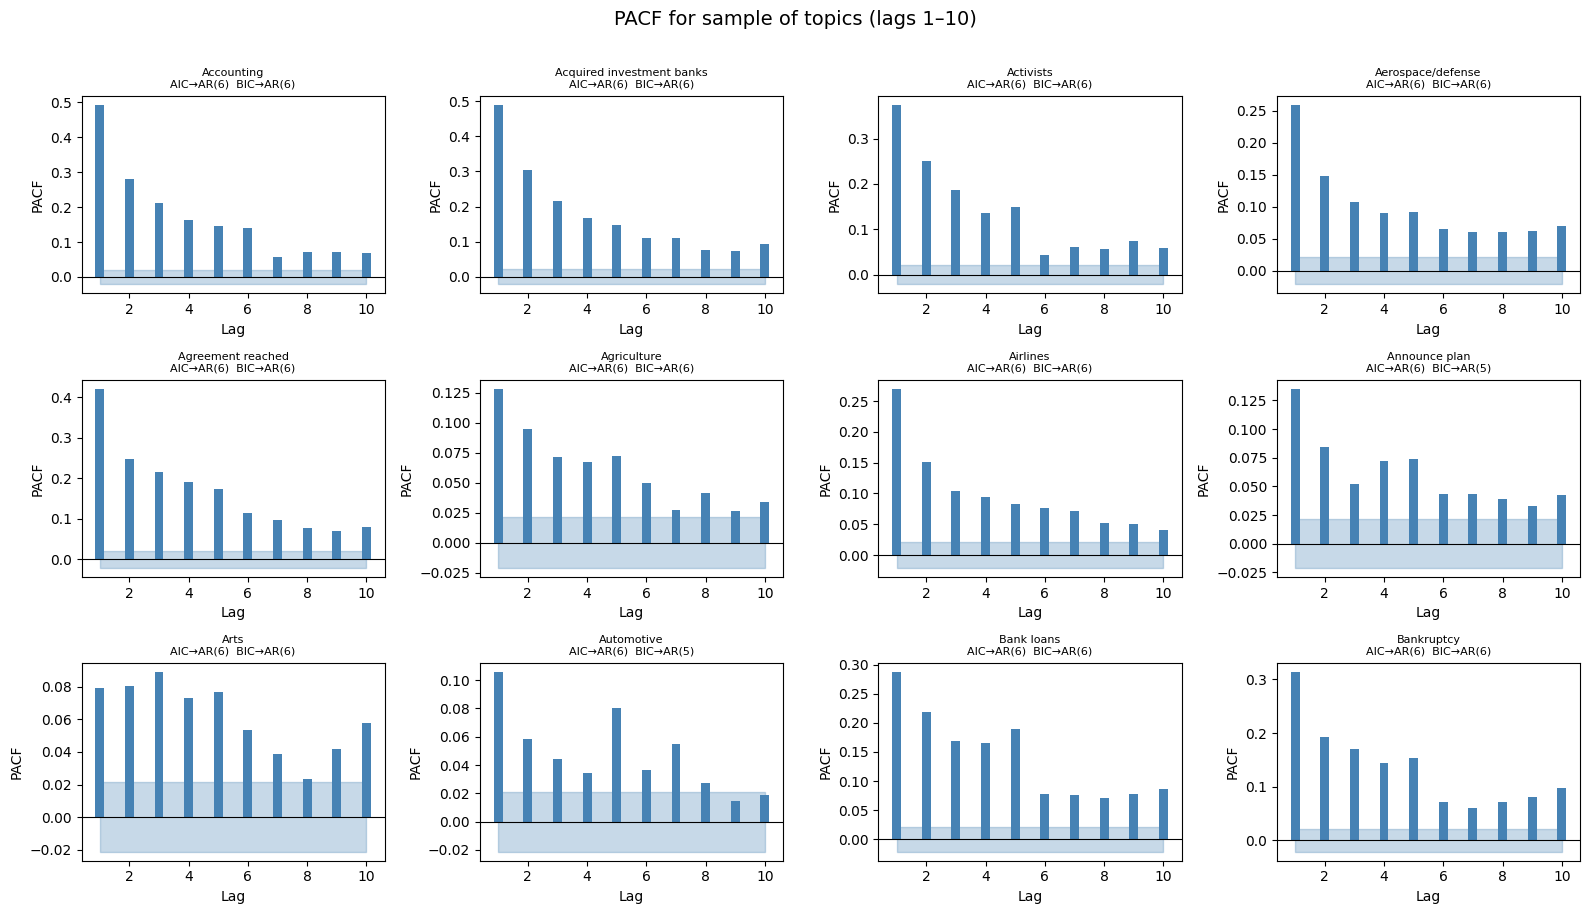

In [9]:
# Select a representative sample: first N_SAMPLE_PACF topics alphabetically
sample_topics = sorted(results_df.index)[:N_SAMPLE_PACF]

ncols = 4
nrows = int(np.ceil(len(sample_topics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, topic in enumerate(sample_topics):
    s = topics_df[topic].dropna()
    try:
        pacf_vals, confint = pacf(s, nlags=10, alpha=0.05)
    except Exception:
        axes[i].set_visible(False)
        continue
    lags = np.arange(len(pacf_vals))
    ci_lower = confint[:, 0] - pacf_vals
    ci_upper = confint[:, 1] - pacf_vals
    axes[i].bar(lags[1:], pacf_vals[1:], color='steelblue', width=0.3)
    axes[i].fill_between(lags[1:], ci_lower[1:], ci_upper[1:], alpha=0.3, color='steelblue')
    axes[i].axhline(0, color='black', linewidth=0.8)
    best_aic = results_df.loc[topic, 'best_aic_order']
    best_bic = results_df.loc[topic, 'best_bic_order']
    axes[i].set_title(f'{topic}\nAIC→AR({best_aic})  BIC→AR({best_bic})', fontsize=8)
    axes[i].set_xlabel('Lag')
    axes[i].set_ylabel('PACF')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('PACF for sample of topics (lags 1–10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. AIC vs BIC agreement

In [10]:
agree = (results_df['best_aic_order'] == results_df['best_bic_order']).sum()
print(f'AIC and BIC agree on best order: {agree}/{n_total}  ({100*agree/n_total:.1f}%)')

# Crosstab of AIC order vs BIC order
ct = pd.crosstab(
    results_df['best_aic_order'],
    results_df['best_bic_order'],
    rownames=['AIC best order'],
    colnames=['BIC best order']
)
print('\nCross-tabulation (AIC rows, BIC columns):')
display(ct)

AIC and BIC agree on best order: 163/180  (90.6%)

Cross-tabulation (AIC rows, BIC columns):


BIC best order,0,1,2,3,4,5,6
AIC best order,,,,,,,
0,2,0,0,0,0,0,0
1,0,2,0,0,0,0,0
5,1,2,1,1,1,21,0
6,0,1,0,0,1,9,138


## 9. Topics where AR(1) assumption is most questionable

In [11]:
# Topics where both AIC and BIC prefer a different order AND AR(1) LB test fails
mask = (
    (results_df['best_aic_order'] != 1) &
    (results_df['best_bic_order'] != 1) &
    (~results_df['ar1_sufficient'])
)
problematic = results_df[mask][['best_aic_order', 'best_bic_order', 'lb_pval_min', 'adf_pval']]
print(f'Topics where AR(1) is clearly wrong (both IC disagree + LB fails): {mask.sum()}')
display(problematic.sort_values('lb_pval_min'))

Topics where AR(1) is clearly wrong (both IC disagree + LB fails): 175


,best_aic_order,best_bic_order,lb_pval_min,adf_pval
topic,,,,
Bankruptcy,6,6,0.000000e+00,1.225973e-07
Spring/summer,6,6,0.000000e+00,2.482541e-06
China,6,6,0.000000e+00,2.203338e-03
California,6,6,0.000000e+00,1.051845e-03
Canada/South Africa,6,6,0.000000e+00,4.412886e-05
...,...,...,...,...
Biology/chemistry/physics,5,3,8.252437e-23,7.463494e-18
Sales call,5,2,5.208461e-20,1.907389e-22
Fees,5,0,1.332853e-16,2.601878e-22


## 10. Summary

Compile the key numbers into a single table.

In [12]:
summary = pd.DataFrame({
    'Metric': [
        'Topics analysed',
        'Stationary (ADF)',
        'Best order = AR(0) by AIC',
        'Best order = AR(1) by AIC',
        'Best order > AR(1) by AIC',
        'Best order = AR(0) by BIC',
        'Best order = AR(1) by BIC',
        'Best order > AR(1) by BIC',
        'AR(1) residuals: white noise (LB)',
        'AR(1) clearly wrong (both IC + LB)',
    ],
    'Count': [
        n_total,
        int(n_stationary),
        int(aic_counts.get(0, 0)),
        int(aic_counts.get(1, 0)),
        int(sum(v for k, v in aic_counts.items() if k > 1)),
        int(bic_counts.get(0, 0)),
        int(bic_counts.get(1, 0)),
        int(sum(v for k, v in bic_counts.items() if k > 1)),
        int(n_sufficient),
        int(mask.sum()),
    ],
})
summary['Pct'] = (summary['Count'] / n_total * 100).round(1).astype(str) + '%'
summary.loc[0, 'Pct'] = ''
display(summary)

,Metric,Count,Pct
0,Topics analysed,180,
1,Stationary (ADF),167,92.8%
2,Best order = AR(0) by AIC,2,1.1%
3,Best order = AR(1) by AIC,2,1.1%
4,Best order > AR(1) by AIC,176,97.8%
5,Best order = AR(0) by BIC,3,1.7%
6,Best order = AR(1) by BIC,5,2.8%
7,Best order > AR(1) by BIC,172,95.6%
8,AR(1) residuals: white noise (LB),0,0.0%
9,AR(1) clearly wrong (both IC + LB),175,97.2%


### Interpretation

- **If AR(1) is the modal choice** under both AIC and BIC, and the majority of Ljung-Box tests pass, the current preprocessing is justified.
- **If AR(0) dominates** (especially under BIC), the innovation extraction adds noise rather than removing persistence, and may be dropped.
- **If higher orders dominate**, a per-topic order selection (via `AutoReg` with `ic='aic'`) would be more appropriate than forcing AR(1) for all topics.
- Topics flagged in Section 9 are the clearest candidates for a different treatment.